In [1]:
import os, warnings, json as _json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor  # RandomForestClassifier removed: not used
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from scipy.stats import randint as sp_randint
from scipy.optimize import minimize  # imported once here — not repeated later

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded. RANDOM_STATE =', RANDOM_STATE)

Libraries loaded. RANDOM_STATE = 42


In [2]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

# Load Datasets

In [3]:
BASE = 'data'
df1_raw = pd.read_csv(f'{BASE}/1. Gym Members Exercise Dataset/gym_members_exercise_tracking.csv')
df2_raw = pd.read_csv(f'{BASE}/2. Exercise and Fitness Metrics Dataset/exercise_dataset.csv')
df_exlib = pd.read_csv(f'{BASE}/3. Fitness Exercises Dataset/exercises_flat.csv')
df_coach = pd.read_excel(f'{BASE}/4. Mendeley Gym Recommendation Dataset/gym recommendation.xlsx')

print('Dataset 1 (Gym Members)       :', df1_raw.shape, '| cols:', df1_raw.columns.tolist())
print('Dataset 2 (Exercise & Fitness):', df2_raw.shape, '| cols:', df2_raw.columns.tolist())
print('Dataset 3 (Exercise Library)  :', df_exlib.shape, '← runtime lookup only')
print('Dataset 4 (Gym Coaching)      :', df_coach.shape, '← runtime lookup only')

Dataset 1 (Gym Members)       : (973, 15) | cols: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Dataset 2 (Exercise & Fitness): (3864, 12) | cols: ['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight', 'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions', 'Exercise Intensity']
Dataset 3 (Exercise Library)  : (30, 8) ← runtime lookup only
Dataset 4 (Gym Coaching)      : (14589, 15) ← runtime lookup only


In [4]:
print('Gym Members Exercise Tracking Dataset (1)')
display(df1_raw.head(3))
print('Exercise and Fitness Metrics Dataset (2)')
display(df2_raw.head(3))
print('Fitness Exercises Dataset (3)')
display(df_exlib.head(3))
print('Mendely Gym Recommendation Dataset (4)')
display(df_coach.head(3))

Gym Members Exercise Tracking Dataset (1)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


Exercise and Fitness Metrics Dataset (2)


,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4


Fitness Exercises Dataset (3)


,exerciseId,name,gifUrl,target_muscles,body_part_category,equipment_needed,secondaryMuscles,instructions
0,2ORFMoR,hack calf raise,2ORFMoR.gif,calves,lower legs,sled machine,hamstrings; glutes,Step:1 Adjust the sled machine to a comfortabl...
1,2Qh2J1e,sled 45Â° leg press (side pov),2Qh2J1e.gif,glutes,upper legs,sled machine,quadriceps; hamstrings; calves,Step:1 Adjust the seat of the sled machine so ...
2,3eGE2JC,dumbbell front raise,3eGE2JC.gif,delts,shoulders,dumbbell,biceps; trapezius,Step:1 Stand with your feet shoulder-width apa...


Mendely Gym Recommendation Dataset (4)


,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment,Diet,Recommendation
0,1,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,2,Male,18,1.68,47.5,Yes,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...
2,3,Male,18,1.68,47.5,No,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor","Vegetables: (Garlic, Roma Tomatoes, Capers and...",Follow a regular exercise schedule. Adhere to ...


In [5]:
print('Dataset 1 — Calories_Burned stats:')
print(df1_raw['Calories_Burned'].describe().round(1))
print()
print('Dataset 2 — Calories Burn stats:')
print(df2_raw['Calories Burn'].describe().round(1))
print()
# Key observations: 
# DS1 range 303-1783 cal (long gym sessions),
# DS2 range 100-500 cal (short exercise bouts). Must handle separately.

Dataset 1 — Calories_Burned stats:
count     973.0
mean      905.4
std       272.6
min       303.0
25%       720.0
50%       893.0
75%      1076.0
max      1783.0
Name: Calories_Burned, dtype: float64

Dataset 2 — Calories Burn stats:
count    3864.0
mean      301.9
std       115.8
min       100.0
25%       202.2
50%       299.7
75%       404.1
max       499.9
Name: Calories Burn, dtype: float64



# Cleaning Datasets Separately
Clean each dataset independently before any merging to ensure schema errors will not propagate.

In [6]:
# Dataset 1: Gym Members

df1 = df1_raw.copy()

assert df1.isnull().sum().sum() == 0, 'DS1 has unexpected NaNs'

print('Dataset 1 cleaned.')
print(f'  Shape : {df1.shape}')
print(f'  Columns: {df1.columns.tolist()}')

Dataset 1 cleaned.
  Shape : (973, 15)
  Columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


In [7]:
# Dataset 2: Exercise & Fitness Metrics
# Rename columns to match DS1 naming convention.

df2 = df2_raw.copy()

df2.drop(columns=['ID', 'Exercise'], inplace=True)
df2.rename(columns={
    'Calories Burn'      : 'Calories_Burned',
    'Actual Weight'      : 'Weight (kg)',
    'Heart Rate'         : 'Avg_BPM',
    'Weather Conditions' : 'Weather_Conditions',
    'Exercise Intensity' : 'Exercise_Intensity',
}, inplace=True)

# DS2 is in MINUTES; DS1 uses HOURS.
df2.rename(columns={'Duration': 'Session_Duration (hours)'}, inplace=True)
df2['Session_Duration (hours)'] = df2['Session_Duration (hours)'] / 60

df2.drop(columns=['Dream Weight'], inplace=True)

assert df2.isnull().sum().sum() == 0, 'DS2 has unexpected NaNs'

print('Dataset 2 cleaned.')
print(f'  Shape : {df2.shape}')
print(f'  Columns: {df2.columns.tolist()}')

Dataset 2 cleaned.
  Shape : (3864, 9)
  Columns: ['Calories_Burned', 'Weight (kg)', 'Age', 'Gender', 'Session_Duration (hours)', 'Avg_BPM', 'BMI', 'Weather_Conditions', 'Exercise_Intensity']


# Dataset Identifier
Tag each row with its source before merging. Because DS1 and DS2 have different calorie distributions.

In [8]:
# source=0 → DS1 (Gym Members, long sessions, 300-1800 cal)
# source=1 → DS2 (Exercise Metrics, short sessions, 100-500 cal)
df1['source'] = 0
df2['source'] = 1

print('Source flags added:')
print(f'  DS1 (source=0): {len(df1)} rows | Calories mean={df1["Calories_Burned"].mean():.0f} cal')
print(f'  DS2 (source=1): {len(df2)} rows | Calories mean={df2["Calories_Burned"].mean():.0f} cal')

Source flags added:
  DS1 (source=0): 973 rows | Calories mean=905 cal
  DS2 (source=1): 3864 rows | Calories mean=302 cal


## Step 4 — Outlier Handling Per Dataset

**Why outliers are handled separately per dataset, before merging:**

DS1 (gym sessions) has a calorie range of ~300–1800 cal and DS2 (short exercise bouts) has ~100–500 cal. Applying IQR on the merged dataset would incorrectly flag DS1's high calorie values (e.g. 1500 cal) as outliers relative to DS2's distribution.

By processing each dataset independently, outliers are judged against their own natural distribution. k=3.0 (3 × IQR) is used rather than the common k=1.5 to preserve valid extreme observations — only genuine measurement errors are removed.

In [9]:
def remove_outliers_iqr(df, col, k=3.0):
    """Remove rows where col is outside [Q1 - k*IQR, Q3 + k*IQR]."""
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - k*IQR, Q3 + k*IQR
    before = len(df)
    df_clean = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'  {col}: removed {before - len(df_clean)} outliers '
          f'(range [{lo:.0f}, {hi:.0f}])')
    return df_clean

print('Outlier removal — DS1:')
df1 = remove_outliers_iqr(df1, 'Calories_Burned')

print('Outlier removal — DS2:')
df2 = remove_outliers_iqr(df2, 'Calories_Burned')

print(f'\nDS1 after outlier removal: {len(df1)} rows')
print(f'DS2 after outlier removal: {len(df2)} rows')

Outlier removal — DS1:
  Calories_Burned: removed 0 outliers (range [-348, 2144])
Outlier removal — DS2:
  Calories_Burned: removed 0 outliers (range [-404, 1010])

DS1 after outlier removal: 973 rows
DS2 after outlier removal: 3864 rows


# Schema Alignment

In [10]:
# Features present in BOTH datasets
COMMON_COLS = [
    'Age',
    'Gender',
    'Weight (kg)',
    'BMI',
    'Avg_BPM',
    'Session_Duration (hours)',
    'Calories_Burned',  # target
    'source',           # dataset identifier
]

# DS1 only features (will be NaN for DS2 rows; imputed with median after merge)
DS1_ONLY = ['Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)',
            'Workout_Frequency (days/week)', 'Experience_Level', 'Workout_Type']

# DS2 only features (will be NaN for DS1 rows; imputed with median after merge)
DS2_ONLY = ['Exercise_Intensity', 'Weather_Conditions']

ALL_SCHEMA_COLS = COMMON_COLS + DS1_ONLY + DS2_ONLY

# Restrict each dataset to only schema columns that exist in it
df1_aligned = df1[[c for c in ALL_SCHEMA_COLS if c in df1.columns]]
df2_aligned = df2[[c for c in ALL_SCHEMA_COLS if c in df2.columns]]

print('DS1 aligned columns:', df1_aligned.columns.tolist())
print('DS2 aligned columns:', df2_aligned.columns.tolist())

DS1 aligned columns: ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'source', 'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'Workout_Type']
DS2 aligned columns: ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'source', 'Exercise_Intensity', 'Weather_Conditions']


# Merging Datasets

In [11]:
# pd.concat to fill missing columns with NaN automatically
df = pd.concat([df1_aligned, df2_aligned], ignore_index=True)

print(f'Merged shape: {df.shape}')
print(f'  source=0 (DS1): {(df["source"]==0).sum()} rows')
print(f'  source=1 (DS2): {(df["source"]==1).sum()} rows')
print()
print('Missing values after merge:')
miss = df.isnull().sum()
print(miss[miss > 0].to_string())

Merged shape: (4837, 16)
  source=0 (DS1): 973 rows
  source=1 (DS2): 3864 rows

Missing values after merge:
Resting_BPM                      3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
Workout_Type                     3864
Exercise_Intensity                973
Weather_Conditions                973


## Step 8 — Post-Merge Encoding & Schema Check

Categorical encoding (Gender, Workout_Type, Weather_Conditions) is applied here on the full merged dataset to ensure **consistent one-hot column structure** across all rows. However, **numeric imputation is deliberately deferred until after the train/test split** (Step 10).

**Why defer imputation?** Fitting imputation statistics (medians, modes) on the full dataset — including test rows — leaks test-set information into training. By computing medians only from training rows (and separately per source to respect each dataset's distribution), we guarantee a fully leakage-free pipeline.

At this stage, NaN values in DS1-only and DS2-only numeric columns are expected and intentional — they will be resolved in the post-split imputation step.

In [12]:
# Verify expected NaN pattern after merge and encoding.
# Imputation is intentionally deferred to after train/test split.
miss = df.isnull().sum()
missing_cols = miss[miss > 0]
print('Expected NaN columns (imputed after split to prevent leakage):')
print(missing_cols.to_string())
print()
assert missing_cols.sum() > 0, 'Expected NaNs not found — check schema alignment'
print(f'Total NaN cells: {missing_cols.sum()} '
      f'({missing_cols.sum() / df.size * 100:.1f}% of DataFrame) — expected and correct at this stage.')

Expected NaN columns (imputed after split to prevent leakage):
Resting_BPM                      3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
Workout_Type                     3864
Exercise_Intensity                973
Weather_Conditions                973

Total NaN cells: 25130 (32.5% of DataFrame) — expected and correct at this stage.


# Categorical Encoding
Apply encoding. Gender → binary. Workout_Type → one-hot. Weather_Conditions → ordinal.

In [13]:
# Gender: Male=1, Female=0 (single consistent encoding)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
assert df['Gender'].isnull().sum() == 0, 'Unknown gender values found'

# Workout_Type: one-hot encode (consistent across the merged set)
df = pd.get_dummies(df, columns=['Workout_Type'], prefix='wt', drop_first=False)
wt_cols = [c for c in df.columns if c.startswith('wt_')]
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Weather_Conditions: ordinal (Rainy < Cloudy < Sunny by activity-friendliness)
weather_map = {'Rainy': 0, 'Cloudy': 1, 'Sunny': 2}
df['Weather_Conditions'] = df['Weather_Conditions'].map(weather_map)

print(f'Encoded. Final shape: {df.shape}')
print(f'Workout type cols: {wt_cols}')
print(f'NaN check: {df.isnull().sum().sum()} total NaNs')

Encoded. Final shape: (4837, 19)
Workout type cols: ['wt_Cardio', 'wt_HIIT', 'wt_Strength', 'wt_Yoga']
NaN check: 21266 total NaNs


In [14]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')
print(f'Final cleaned shape: {df.shape}')

Duplicates removed: 0
Final cleaned shape: (4837, 19)


# Feature Engineering
**Log-transform the target** to normalise its right-skewed distribution.

In [15]:
# ── Feature Engineering ─────────────────────────────────────────────────
# Only columns available at prediction time are used.
# NOTE: HR_Reserve uses Resting_BPM (NaN for DS2 rows) and
#       Intensity_Duration uses Exercise_Intensity (NaN for DS1 rows).
# These NaN values propagate into the derived features and are resolved
# in the post-split imputation step.

# BPM features — standard exercise physiology formulas
df['Max_BPM_calc']       = 220 - df['Age']                         # Haskell & Fox (1970)
df['HR_Reserve']         = df['Max_BPM_calc'] - df['Resting_BPM']  # Karvonen method
df['HR_Intensity_Ratio'] = df['Avg_BPM'] / df['Max_BPM_calc']      # effort zone %

# Interaction features: effort × time
df['HR_Duration']        = df['Avg_BPM']            * df['Session_Duration (hours)']
df['Intensity_Duration'] = df['Exercise_Intensity'] * df['Session_Duration (hours)']
df['Weight_Duration']    = df['Weight (kg)']        * df['Session_Duration (hours)']
df['BMI_Duration']       = df['BMI']                * df['Session_Duration (hours)']

# Log-transform the target variable
# Calories_Burned is right-skewed (DS1 mean ~905, DS2 mean ~302)
# Log-transform makes the distribution more normal, improving model convergence
# All predictions are inverse-transformed with np.expm1() at evaluation
df['log_Calories'] = np.log1p(df['Calories_Burned'])

print('Engineered features created.')
derived = ['HR_Reserve', 'HR_Intensity_Ratio', 'HR_Duration',
           'Intensity_Duration', 'Weight_Duration', 'BMI_Duration']
for col in derived:
    n = df[col].isnull().sum()
    if n > 0:
        print(f'  {col}: {n} NaNs (expected — resolved after split)')
print(f'DataFrame shape: {df.shape}')

Engineered features created.
  HR_Reserve: 3864 NaNs (expected — resolved after split)
  Intensity_Duration: 973 NaNs (expected — resolved after split)
DataFrame shape: (4837, 27)


## Exploratory Data Analysis

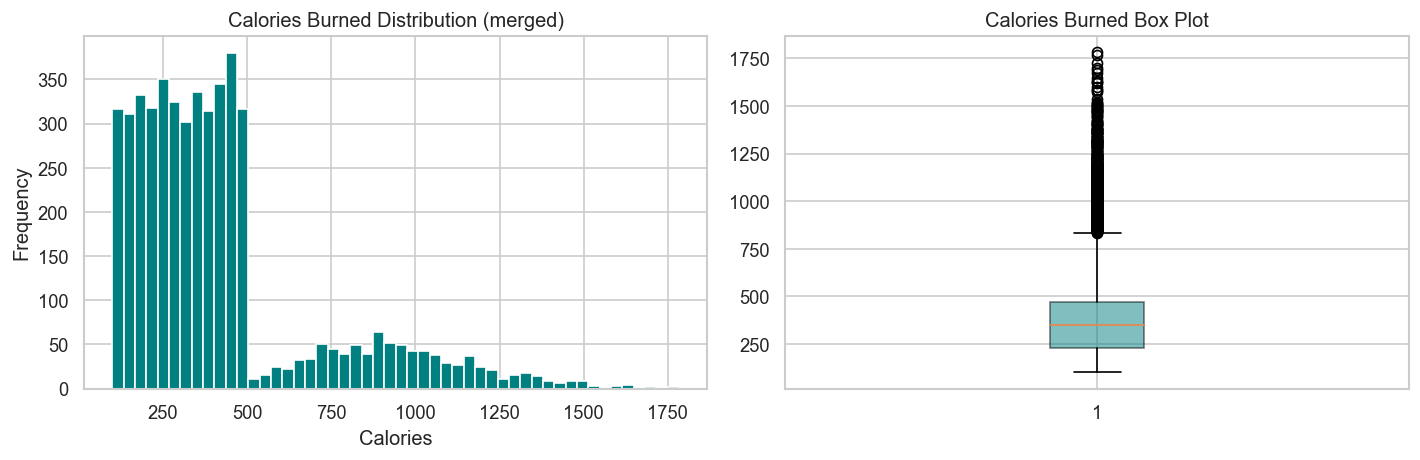

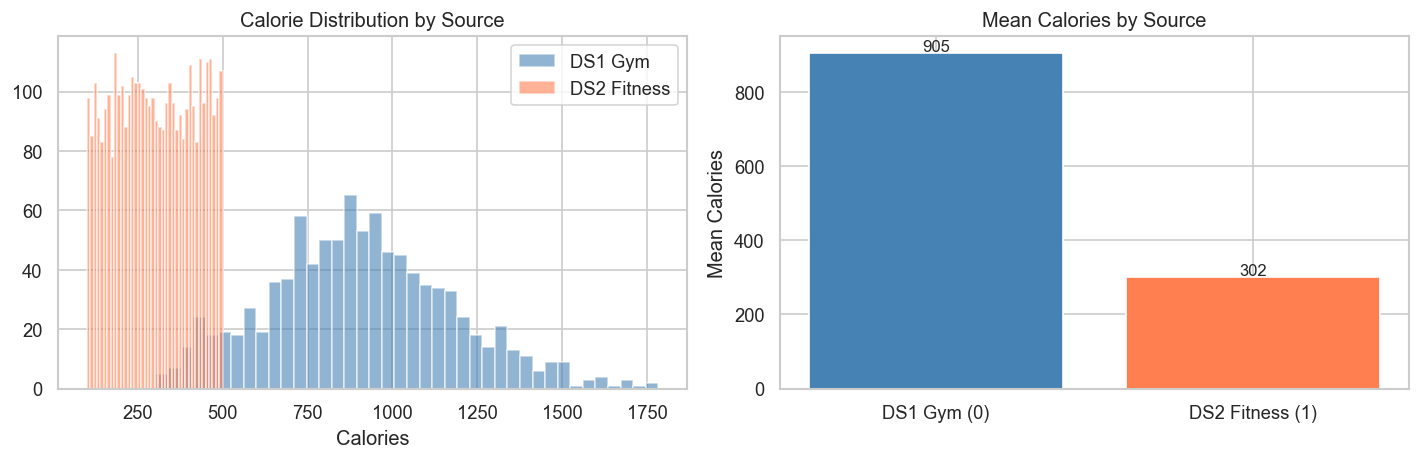

DS1 mean = 905 cal  |  DS2 mean = 302 cal
Note: source is used for analysis and sample weighting only — NOT a model feature.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Calories_Burned'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Calories Burned Distribution (merged)')
axes[0].set_xlabel('Calories'); axes[0].set_ylabel('Frequency')
axes[1].boxplot(df['Calories_Burned'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.5))
axes[1].set_title('Calories Burned Box Plot')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for src, label, color in [(0,'DS1 Gym','steelblue'), (1,'DS2 Fitness','coral')]:
    axes[0].hist(df[df['source']==src]['Calories_Burned'], bins=40,
                 alpha=0.6, label=label, color=color)
axes[0].set_title('Calorie Distribution by Source')
axes[0].legend(); axes[0].set_xlabel('Calories')
src_means = df.groupby('source')['Calories_Burned'].mean()
axes[1].bar(['DS1 Gym (0)', 'DS2 Fitness (1)'], src_means.values,
            color=['steelblue', 'coral'])
axes[1].set_title('Mean Calories by Source')
axes[1].set_ylabel('Mean Calories')
for i, v in enumerate(src_means.values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

# FIX: previous version said 'source is critical for the model'.
# source is EXCLUDED from training features (see train/test split cell).
# Sample weights handle the DS1/DS2 imbalance during model training instead.
print(f'DS1 mean = {src_means[0]:.0f} cal  |  DS2 mean = {src_means[1]:.0f} cal')
print('Note: source is used for analysis and sample weighting only — NOT a model feature.')

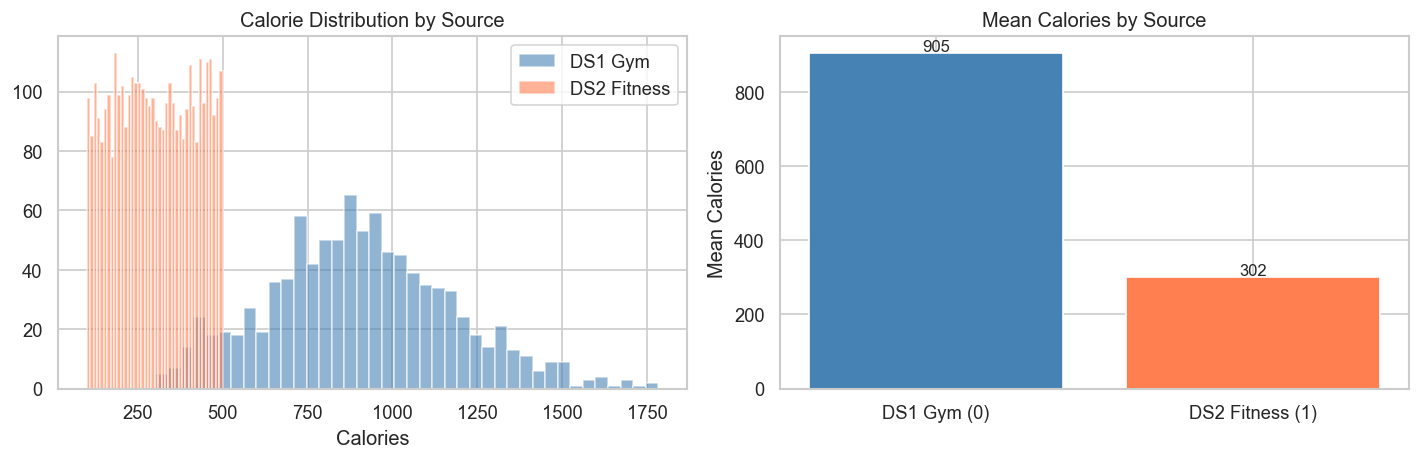

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for src, label, color in [(0,'DS1 Gym','steelblue'), (1,'DS2 Fitness','coral')]:
    axes[0].hist(df[df['source']==src]['Calories_Burned'], bins=40,
                 alpha=0.6, label=label, color=color)
axes[0].set_title('Calorie Distribution by Source')
axes[0].legend(); axes[0].set_xlabel('Calories')
src_means = df.groupby('source')['Calories_Burned'].mean()
axes[1].bar(['DS1 Gym (0)','DS2 Fitness (1)'], src_means.values, color=['steelblue','coral'])
axes[1].set_title('Mean Calories by Source')
axes[1].set_ylabel('Mean Calories')
for i, v in enumerate(src_means.values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=10)
plt.tight_layout(); 
plt.show()

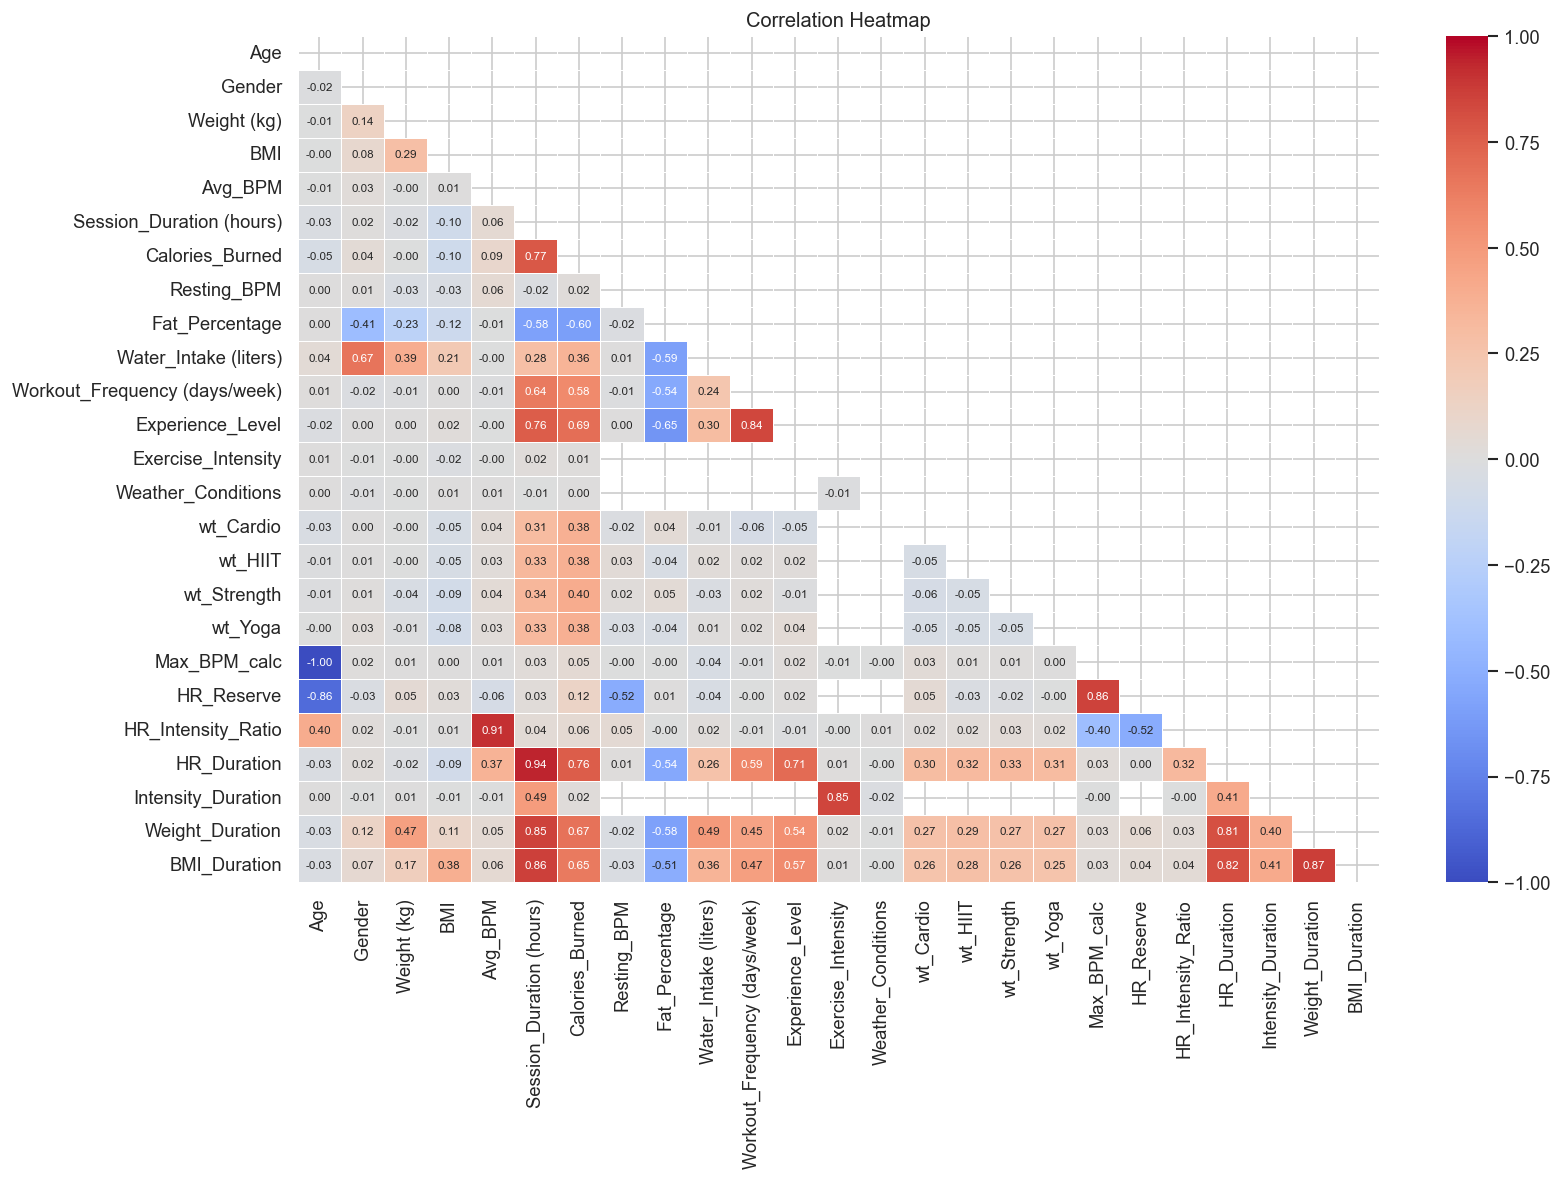

In [18]:
numeric_df = df.select_dtypes(include='number').drop(columns=['log_Calories','source'], errors='ignore')
corr = numeric_df.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.tight_layout(); 
plt.show()

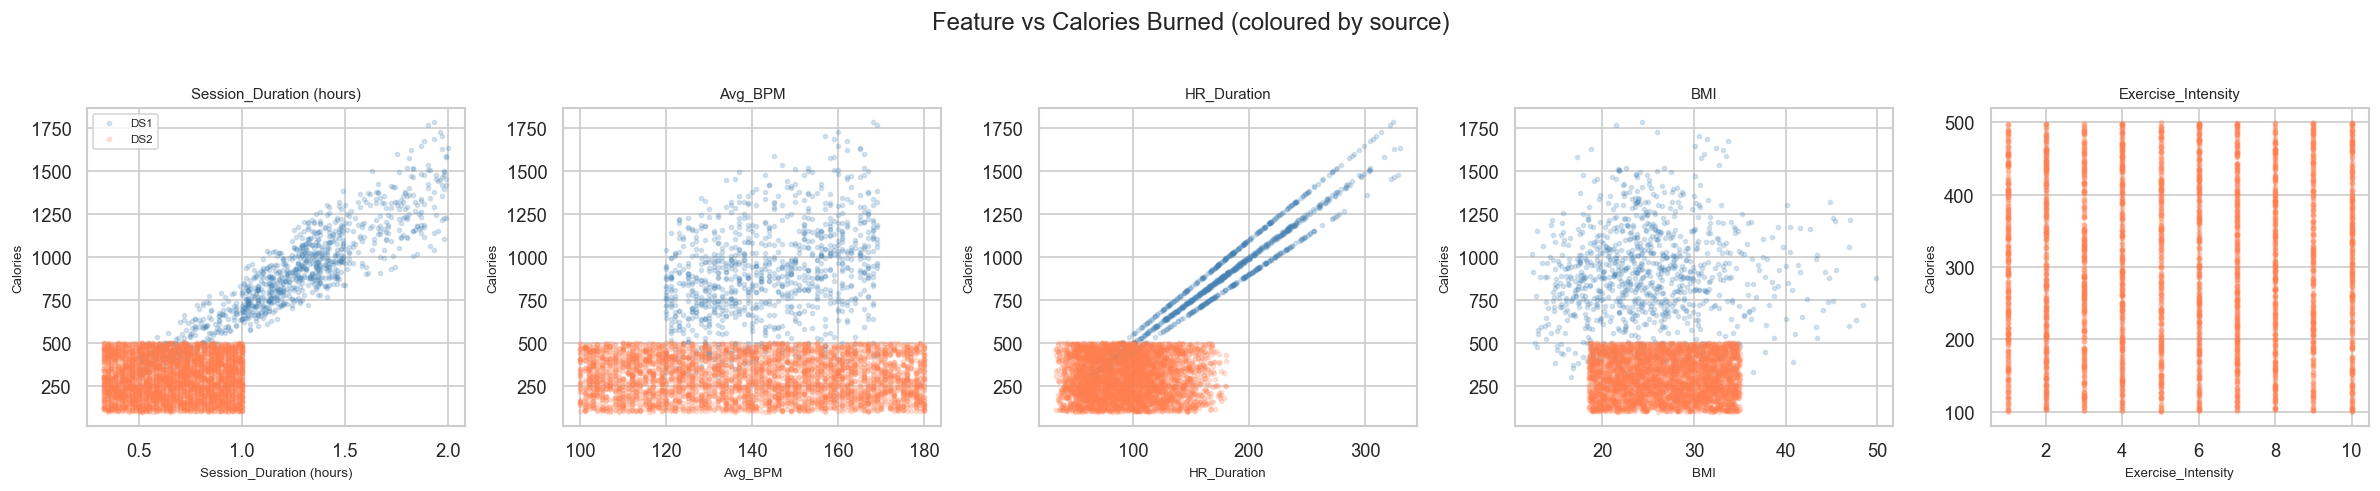

In [19]:
scatter_cols = ['Session_Duration (hours)', 'Avg_BPM', 'HR_Duration', 'BMI', 'Exercise_Intensity']
fig, axes = plt.subplots(1, len(scatter_cols), figsize=(20, 4))
for ax, col in zip(axes, scatter_cols):
    for src, color, label in [(0,'steelblue','DS1'), (1,'coral','DS2')]:
        m = df['source'] == src
        ax.scatter(df.loc[m, col], df.loc[m, 'Calories_Burned'],
                   alpha=0.2, s=6, color=color, label=label)
    ax.set_xlabel(col, fontsize=8); ax.set_ylabel('Calories', fontsize=8)
    ax.set_title(col, fontsize=9)
axes[0].legend(fontsize=7)
plt.suptitle('Feature vs Calories Burned (coloured by source)', y=1.02)
plt.tight_layout(); 
plt.show()

# Train/Test Split (BEFORE Feature Selection)
The split MUST happen before feature selection to prevent leakage. Feature importances are computed **only on training data**.

In [20]:
# Leakage guard + source exclusion
# `source` is a dataset identifier — must NOT be a model feature.
# Per coursework requirement: remove before training.
# Sample weights (computed next cell) handle the DS1/DS2 imbalance instead.
TARGET_LEAK_COLS = {'Calories_Burned', 'log_Calories', 'source'}

CANDIDATE_FEATURES = [
    c for c in df.columns
    if c not in TARGET_LEAK_COLS
]

X_all = df[CANDIDATE_FEATURES].copy()
y_raw = df['Calories_Burned'].copy()   # original scale — evaluation only
y_log = df['log_Calories'].copy()      # log scale — model training

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_log, test_size=0.20, random_state=RANDOM_STATE
)

_idx        = y_test.index
y_test_raw  = y_raw.loc[_idx]
y_train_raw = y_raw.loc[X_train.index]
# source labels fetched from df (not from X_train — source was excluded)
src_test    = df.loc[_idx, 'source']

print(f'Train set : {X_train.shape}')
print(f'Test set  : {X_test.shape}')
print(f'Features  : {X_train.columns.tolist()}')
print('Note: source excluded from features — sample weights handle DS1/DS2 imbalance.')

Train set : (3869, 24)
Test set  : (968, 24)
Features  : ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Avg_BPM', 'Session_Duration (hours)', 'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'Exercise_Intensity', 'Weather_Conditions', 'wt_Cardio', 'wt_HIIT', 'wt_Strength', 'wt_Yoga', 'Max_BPM_calc', 'HR_Reserve', 'HR_Intensity_Ratio', 'HR_Duration', 'Intensity_Duration', 'Weight_Duration', 'BMI_Duration']
Note: source excluded from features — sample weights handle DS1/DS2 imbalance.


In [21]:
# Sample weights: upweight DS1 rows to balance the 4:1 DS2/DS1 ratio.
# Without this the model disproportionately optimises for DS2's calorie range.
src_train = df.loc[X_train.index, 'source']
w0 = len(src_train) / (2 * (src_train == 0).sum())
w1 = len(src_train) / (2 * (src_train == 1).sum())
sample_weights = src_train.map({0: w0, 1: w1}).values
print(f'Sample weights  DS1={w0:.3f}  DS2={w1:.3f}')

Sample weights  DS1=2.535  DS2=0.623


In [22]:
# Note on scaling strategy:
# The scaler (StandardScaler) is fitted AFTER feature selection in Cell 37.
# Fitting it here on all 24 candidate features is wasteful — the scaler gets
# refitted on the ~10 selected features after selection, overwriting this.
#
# Scaling is only needed for:
#   - Ridge Regression + Polynomial Features (use_sc=True in evaluate)
#   - ANN (uses X_train_sc directly)
# Tree-based models (Random Forest, XGBoost) are scale-invariant and use
#   X_train / X_test unscaled (use_sc=False), as shown in their model cells.
print('Scaler note: will be fitted on selected features in Cell 37 (after feature selection).')

Scaler note: will be fitted on selected features in Cell 37 (after feature selection).


In [23]:
# ── Step 10: Post-Split Imputation (Fit on Training Data Only) ──────────
#
# Imputation strategy:
#   1. Statistics computed from TRAINING rows only — no test leakage.
#   2. Per-source medians: DS1-only columns use DS1 train-row medians;
#      DS2-only columns use DS2 train-row medians.
#      This respects each dataset's own distribution rather than blending them.
#   3. Derived features that inherited NaNs (HR_Reserve, Intensity_Duration)
#      are filled using the all-training median as a fallback.

# Source labels for train/test (source excluded from X_train/X_test)
src_tr = df.loc[X_train.index, 'source']
src_te = df.loc[X_test.index,  'source']

tr_ds1_idx = X_train.index[src_tr == 0]
tr_ds2_idx = X_train.index[src_tr == 1]
te_ds1_idx = X_test.index[src_te == 0]
te_ds2_idx = X_test.index[src_te == 1]

impute_values = {}  # saved for inference-time use

def _impute_col(col, train_ref_idx, test_fill_idx, label):
    """Fill NaNs using median from train_ref_idx rows, apply to test_fill_idx."""
    n_tr = X_train.loc[train_ref_idx.union(X_train.index.difference(train_ref_idx)), col].isnull().sum()
    actual_nan_tr = X_train[col].isnull().sum()
    if actual_nan_tr == 0:
        return
    med = float(X_train.loc[train_ref_idx, col].median())
    impute_values[col] = med
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)
    print(f'  {col:<40s} {label} median={med:.2f}  ({actual_nan_tr} train NaNs)')

print('DS1-only columns → median from DS1 training rows:')
DS1_ONLY_NUM = ['Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)',
                'Workout_Frequency (days/week)', 'Experience_Level']
for col in DS1_ONLY_NUM:
    if col in X_train.columns:
        _impute_col(col, tr_ds1_idx, te_ds2_idx, 'DS1-train')

print('\nDS2-only columns → median from DS2 training rows:')
DS2_ONLY_NUM = ['Exercise_Intensity', 'Weather_Conditions']
for col in DS2_ONLY_NUM:
    if col in X_train.columns:
        _impute_col(col, tr_ds2_idx, te_ds1_idx, 'DS2-train')

# Derived features that inherited NaNs from their source columns
remaining = [c for c in X_train.columns if X_train[c].isnull().sum() > 0]
if remaining:
    print('\nDerived features (residual NaNs → all-training median):')
    for col in remaining:
        med = float(X_train[col].median())
        impute_values[col] = med
        n = X_train[col].isnull().sum()
        X_train[col] = X_train[col].fillna(med)
        X_test[col]  = X_test[col].fillna(med)
        print(f'  {col:<40s} all-train median={med:.2f}  ({n} NaNs)')

# Final verification
assert X_train.isnull().sum().sum() == 0, 'Train NaNs remain!'
assert X_test.isnull().sum().sum()  == 0, 'Test NaNs remain!'
print(f'\nImputation complete. {len(impute_values)} column values stored.')
print('Stored medians are fitted on TRAINING DATA ONLY — no leakage.')

DS1-only columns → median from DS1 training rows:
  Resting_BPM                              DS1-train median=63.00  (3106 train NaNs)
  Fat_Percentage                           DS1-train median=26.20  (3106 train NaNs)
  Water_Intake (liters)                    DS1-train median=2.60  (3106 train NaNs)
  Workout_Frequency (days/week)            DS1-train median=3.00  (3106 train NaNs)
  Experience_Level                         DS1-train median=2.00  (3106 train NaNs)

DS2-only columns → median from DS2 training rows:
  Exercise_Intensity                       DS2-train median=6.00  (763 train NaNs)
  Weather_Conditions                       DS2-train median=1.00  (763 train NaNs)

Derived features (residual NaNs → all-training median):
  HR_Reserve                               all-train median=119.00  (3106 NaNs)
  Intensity_Duration                       all-train median=3.33  (763 NaNs)

Imputation complete. 9 column values stored.
Stored medians are fitted on TRAINING DATA ONLY — n

# Feature Selection (Training Data Only)
Use two complementary methods to select features. Running on training data only prevents leakage. Using two methods reduces false positives from any single method.

In [24]:
# Method 1: Random Forest Importance (fast, purity-based)
print('RF Importance (on training set)')
rf_sel = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train, y_train, sample_weight=sample_weights)
rf_imp = pd.Series(rf_sel.feature_importances_, index=X_train.columns)

# Method 2: Permutation Importance (model-agnostic, unbiased)
print('Permutation Importance (on training set)')
perm = permutation_importance(
    rf_sel, X_train, y_train,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
perm_imp = pd.Series(np.clip(perm.importances_mean, 0, None), index=X_train.columns)

# Normalise 0-1 and average
def norm01(s): return (s - s.min()) / (s.max() - s.min() + 1e-12)

fs_scores = pd.DataFrame({
    'RF Importance'         : norm01(rf_imp),
    'Permutation Importance': norm01(perm_imp),
})
fs_scores['Combined Score'] = fs_scores.mean(axis=1)
fs_scores = fs_scores.sort_values('Combined Score', ascending=False)

print('\nFeature scores (sorted):')
print(fs_scores.round(3).to_string())

RF Importance (on training set)
Permutation Importance (on training set)

Feature scores (sorted):
                               RF Importance  Permutation Importance  Combined Score
Session_Duration (hours)               1.000                   1.000           1.000
HR_Duration                            0.097                   0.276           0.187
BMI_Duration                           0.032                   0.229           0.130
Experience_Level                       0.108                   0.144           0.126
Weight (kg)                            0.035                   0.173           0.104
HR_Intensity_Ratio                     0.033                   0.168           0.101
Weight_Duration                        0.030                   0.147           0.088
BMI                                    0.034                   0.141           0.088
Intensity_Duration                     0.028                   0.136           0.082
Avg_BPM                                0.021       

In [25]:
THRESHOLD = 0.05
selected_features = fs_scores[
    fs_scores['Combined Score'] > THRESHOLD
].index.tolist()

# Leakage assertion: target and its transform must never appear as features
assert 'Calories_Burned' not in selected_features, 'Target leakage!'
assert 'log_Calories'    not in selected_features, 'Target leakage!'

print(f'{len(selected_features)} features selected (combined score > {THRESHOLD}):')
for f in selected_features:
    print(f'  - {f}')

# Apply selection: restrict train and test to selected columns only
X_train = X_train[selected_features]
X_test  = X_test[selected_features]

# Fit scaler on SELECTED TRAINING FEATURES only.
# Fitted here (after selection) so scaler dimensions match the final feature set.
# Tree models: scale-invariant — use X_train / X_test directly (use_sc=False).
# Ridge, ANN: use X_train_sc / X_test_sc (use_sc=True).
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on training set only
X_test_sc  = scaler.transform(X_test)        # apply same parameters to test

print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')
print('Scaler fitted on training set only — no leakage.')

10 features selected (combined score > 0.05):
  - Session_Duration (hours)
  - HR_Duration
  - BMI_Duration
  - Experience_Level
  - Weight (kg)
  - HR_Intensity_Ratio
  - Weight_Duration
  - BMI
  - Intensity_Duration
  - Avg_BPM

Train: (3869, 10)  Test: (968, 10)
Scaler fitted on training set only — no leakage.


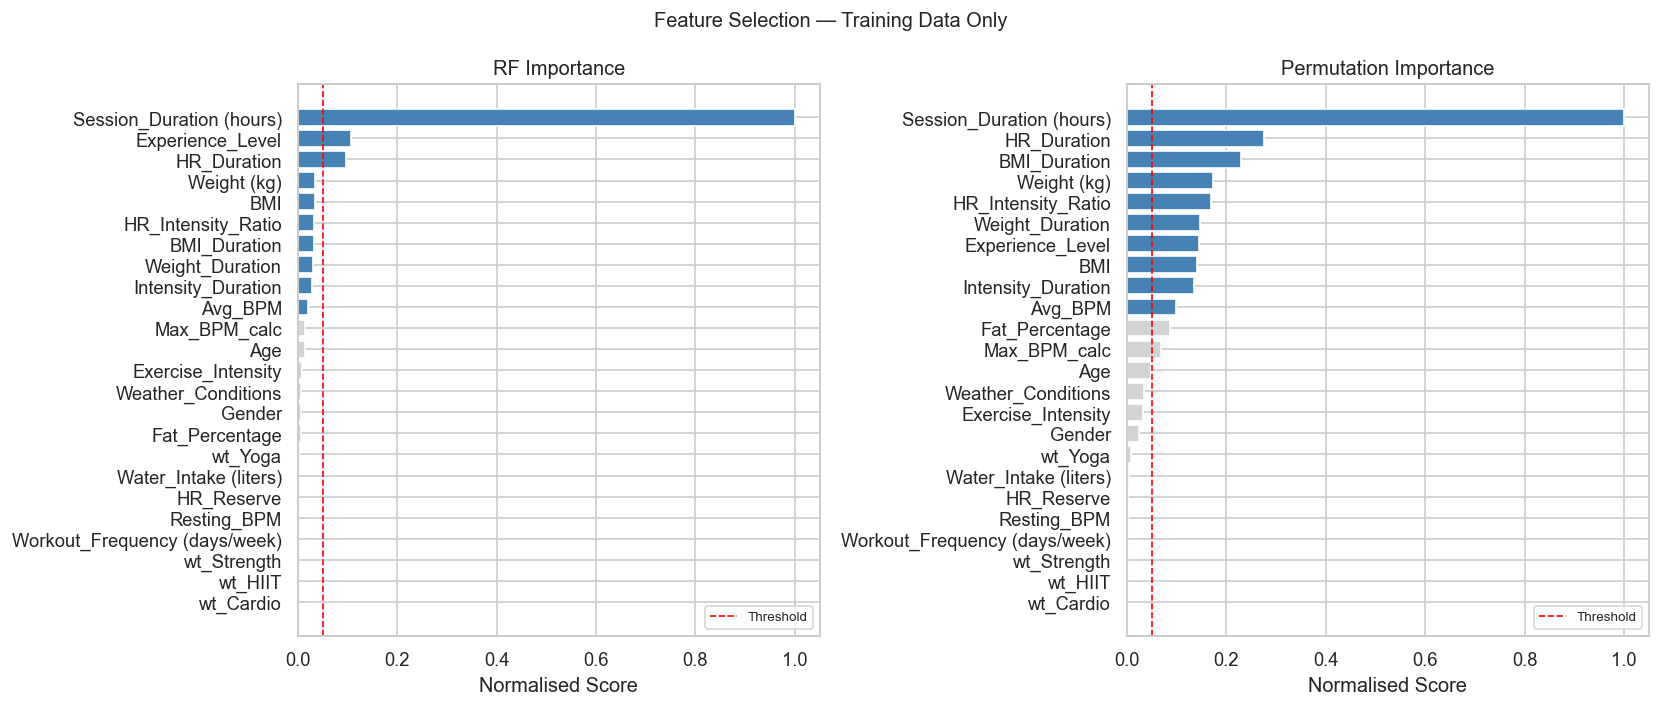

In [26]:
# Feature importance bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, method in zip(axes, ['RF Importance', 'Permutation Importance']):
    top = fs_scores[method].sort_values(ascending=True)
    colors = ['steelblue' if fs_scores.loc[f,'Combined Score'] > THRESHOLD else 'lightgray'
              for f in top.index]
    ax.barh(top.index, top.values, color=colors)
    ax.set_title(method)
    ax.set_xlabel('Normalised Score')
    ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
    ax.legend(fontsize=8)
plt.suptitle('Feature Selection — Training Data Only', fontsize=12)
plt.tight_layout(); plt.show()

# Model Training
All models trained on log-transformed target. Predictions are inverse-transformed (`expm1`) for metric reporting in original calorie scale.

In [27]:
# Helper function for model evaluation
CALORIE_BINS   = [0, 400, 700, 1000, 9999]
CALORIE_LABELS = ['Low', 'Medium', 'High', 'Very High']
results = {}

def _cv_orig_r2(estimator, X, y_log):
    """Custom CV scorer: predict in log space, score R² in original calorie scale."""
    p = np.expm1(np.clip(estimator.predict(X), 0, None))
    a = np.expm1(np.clip(np.asarray(y_log), 0, None))
    return r2_score(a, p)

def evaluate(name, model, Xtr, Xte, ytr, yte_raw, use_sc=False):
    """Evaluate model: metrics in original calorie scale, CV R² consistent."""
    Xtr_cv = Xtr if not use_sc else X_train_sc
    Xte_e  = Xte if not use_sc else X_test_sc

    pred = np.expm1(np.clip(model.predict(Xte_e), 0, None))
    act  = yte_raw.values

    mae  = mean_absolute_error(act, pred)
    rmse = np.sqrt(mean_squared_error(act, pred))
    r2   = r2_score(act, pred)
    mape = np.mean(np.abs((act - pred) / np.clip(act, 1, None))) * 100
    err  = np.abs(act - pred)
    a50  = (err <=  50).mean() * 100
    a100 = (err <= 100).mean() * 100
    a150 = (err <= 150).mean() * 100

    ab = pd.cut(pd.Series(act),  bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
    pb = pd.cut(pd.Series(pred), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
    f1 = f1_score(ab, pb, average='weighted', zero_division=0)

    # FIX: `fit_params=` was removed from cross_val_score in sklearn 1.6+.
    # CV without sample weights gives a valid generalisation estimate.
    # Sample weights are applied in the actual model .fit() — that is what matters.
    cv = cross_val_score(model, Xtr_cv, ytr, cv=5,
                         scoring=_cv_orig_r2, n_jobs=-1)

    results[name] = dict(
        MAE=mae, RMSE=rmse, R2=r2, MAPE=mape,
        **{'Acc@50': a50, 'Acc@100': a100, 'Acc@150': a150,
           'BinnedF1': f1, 'CV_R2': cv.mean(), 'CV_std': cv.std()}
    )
    print(f'  MAE         = {mae:.2f} cal')
    print(f'  RMSE        = {rmse:.2f} cal')
    print(f'  R²          = {r2:.4f}')
    print(f'  MAPE        = {mape:.2f}%')
    print(f'  Acc ±50      = {a50:.1f}%')
    print(f'  Acc ±100     = {a100:.1f}%')
    print(f'  Acc ±150     = {a150:.1f}%')
    print(f'  Binned F1   = {f1:.4f}')
    print(f'  CV R² (orig) = {cv.mean():.4f} ± {cv.std():.4f}')
    return pred

print('evaluate() ready. CV R² in original calorie scale, no fit_params.')

evaluate() ready. CV R² in original calorie scale, no fit_params.


In [28]:
# Model 1: Ridge Regression + Polynomial Interactions
# Rationale: PolynomialFeatures adds pairwise interaction terms
# (e.g. HR x Duration) without overfitting (Ridge L2 penalty controls this).
print('Ridge + Polynomial Interactions:')
lr_pipe = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('ridge', Ridge(alpha=10.0))
])
lr_pipe.fit(X_train_sc, y_train)
pred_lr = evaluate('Linear Regression', lr_pipe,
                   X_train_sc, X_test_sc, y_train, y_test_raw, use_sc=True)
lr = lr_pipe

Ridge + Polynomial Interactions:
  MAE         = 127.48 cal
  RMSE        = 173.66 cal
  R²          = 0.6529
  MAPE        = 38.03%
  Acc ±50      = 25.4%
  Acc ±100     = 48.8%
  Acc ±150     = 67.8%
  Binned F1   = 0.6551
  CV R² (orig) = 0.6134 ± 0.0547


In [29]:
# Model 2: Random Forest
print('Random Forest Regressor:')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=3,
    min_samples_leaf=2, max_features='sqrt',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=sample_weights)
pred_rf = evaluate('Random Forest', rf, X_train, X_test, y_train, y_test_raw)

Random Forest Regressor:
  MAE         = 89.74 cal
  RMSE        = 109.58 cal
  R²          = 0.8618
  MAPE        = 32.64%
  Acc ±50      = 34.0%
  Acc ±100     = 61.7%
  Acc ±150     = 79.4%
  Binned F1   = 0.7192
  CV R² (orig) = 0.8502 ± 0.0144


In [30]:
# Model 3: XGBoost
# eval_set uses a held-out split from TRAINING data (never the test set).
print('XGBoost Regressor:')
_Xtr2, _Xval, _ytr2, _yval, _sw2, _ = train_test_split(
    X_train, y_train, sample_weights, test_size=0.15, random_state=RANDOM_STATE
)
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4,
    subsample=0.9, colsample_bytree=0.9,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)
xgb.fit(_Xtr2, _ytr2, sample_weight=_sw2,
        eval_set=[(_Xval, _yval)], verbose=False)
pred_xgb = evaluate('XGBoost', xgb, X_train, X_test, y_train, y_test_raw)

XGBoost Regressor:
  MAE         = 88.86 cal
  RMSE        = 110.10 cal
  R²          = 0.8605
  MAPE        = 32.59%
  Acc ±50      = 35.0%
  Acc ±100     = 61.7%
  Acc ±150     = 78.9%
  Binned F1   = 0.7243
  CV R² (orig) = 0.8423 ± 0.0156


ANN (LeakyReLU + L2 + Huber):
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  MAE=99.21  RMSE=120.49  R²=0.8329
  Acc±100=55.6%  BinnedF1=0.7075


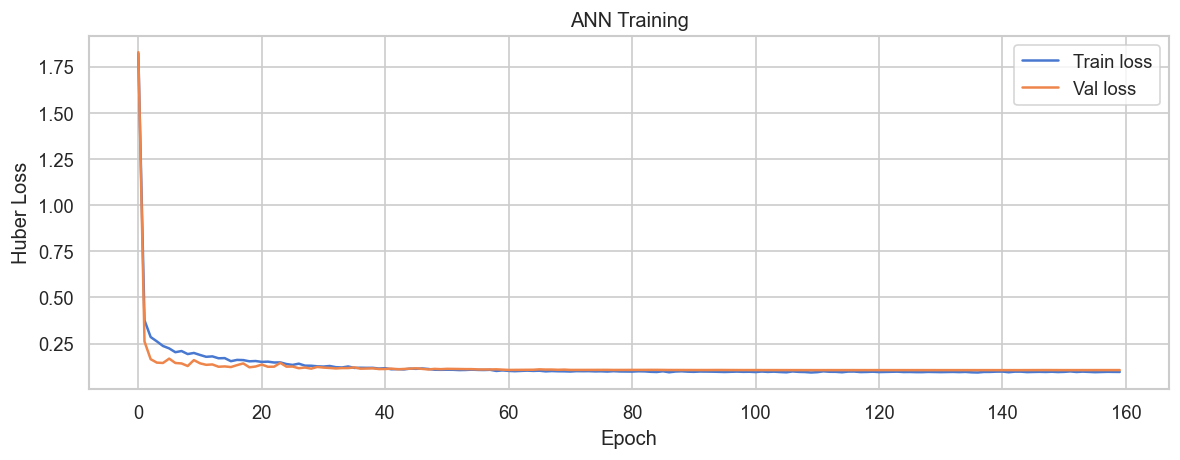

In [31]:
# Model 4: ANN (LeakyReLU + L2 + Huber Loss + sample weights)
print('ANN (LeakyReLU + L2 + Huber):')
n_f = X_train_sc.shape[1]
REG = l2(1e-4)

ann = Sequential([
    Dense(256, kernel_regularizer=REG, input_shape=(n_f,)), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.3),
    Dense(128, kernel_regularizer=REG), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.2),
    Dense(64,  kernel_regularizer=REG), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.1),
    Dense(32,  kernel_regularizer=REG), LeakyReLU(0.1),
    Dense(1)
])
ann.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])

_split = int(len(X_train_sc) * 0.85)
history = ann.fit(
    X_train_sc[:_split], y_train.values[:_split],
    sample_weight=sample_weights[:_split],
    validation_data=(X_train_sc[_split:], y_train.values[_split:]),
    epochs=300, batch_size=32,
    callbacks=[EarlyStopping(patience=20, restore_best_weights=True),
               ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)],
    verbose=0
)

pred_ann = np.expm1(np.clip(ann.predict(X_test_sc).flatten(), 0, None))
act = y_test_raw.values
err_a = np.abs(act - pred_ann)
ab = pd.cut(pd.Series(act),       bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pb = pd.cut(pd.Series(pred_ann),  bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
results['ANN'] = dict(
    MAE=mean_absolute_error(act,pred_ann), RMSE=float(np.sqrt(mean_squared_error(act,pred_ann))),
    R2=r2_score(act,pred_ann),
    MAPE=np.mean(np.abs((act-pred_ann)/np.clip(act,1,None)))*100,
    **{'Acc@50':(err_a<=50).mean()*100,'Acc@100':(err_a<=100).mean()*100,
       'Acc@150':(err_a<=150).mean()*100,
       'BinnedF1':f1_score(ab,pb,average='weighted',zero_division=0),
       'CV_R2':float('nan'),'CV_std':float('nan')})
r=results['ANN']
print(f'  MAE={r["MAE"]:.2f}  RMSE={r["RMSE"]:.2f}  R²={r["R2"]:.4f}')
print(f'  Acc±100={r["Acc@100"]:.1f}%  BinnedF1={r["BinnedF1"]:.4f}')

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.title('ANN Training')
plt.legend(); plt.tight_layout(); plt.show()

## Hyperparameter Tuning (RandomizedSearchCV)
Tuned on training data only. The custom scorer evaluates R² in original calorie scale for consistency.

In [32]:
# RF Hyperparameter Tuning
# Tune on unweighted data to find best structural params; refit with weights.
rf_param_dist = {
    'n_estimators'     : sp_randint(200, 800),
    'max_depth'        : [8, 10, 12, 15, 20, None],
    'min_samples_split': sp_randint(2, 12),
    'min_samples_leaf' : sp_randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6],
    'bootstrap'        : [True, False],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=60, cv=5, scoring=_cv_orig_r2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
# FIX: do NOT pass sample_weight here — requires metadata routing in sklearn 1.4+.
# Hyperparameter search on unweighted data is still valid (finds optimal structure).
rf_search.fit(X_train, y_train)
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV R²    : {rf_search.best_score_:.4f}')

# Refit best estimator with sample weights for the final model
rf_tuned = RandomForestRegressor(**rf_search.best_params_,
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_train, y_train, sample_weight=sample_weights)
pred_rf_tuned = evaluate('RF (tuned)', rf_tuned,
                         X_train, X_test, y_train, y_test_raw)
print(f'CV R² gain: {results["Random Forest"]["CV_R2"]:.4f} → '
      f'{results["RF (tuned)"]["CV_R2"]:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best RF params: {'bootstrap': True, 'max_depth': 8, 'max_features': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 201}
Best CV R²    : 0.8526
  MAE         = 88.94 cal
  RMSE        = 108.29 cal
  R²          = 0.8650
  MAPE        = 32.41%
  Acc ±50      = 34.2%
  Acc ±100     = 61.6%
  Acc ±150     = 79.5%
  Binned F1   = 0.7202
  CV R² (orig) = 0.8526 ± 0.0146
CV R² gain: 0.8502 → 0.8526


In [33]:
# XGBoost Hyperparameter Tuning
xgb_param_dist = {
    'n_estimators'     : sp_randint(200, 700),
    'learning_rate'    : [0.01, 0.02, 0.05, 0.08, 0.1],
    'max_depth'        : sp_randint(3, 8),
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight' : sp_randint(1, 8),
    'gamma'            : [0, 0.1, 0.2, 0.5],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=60, cv=5, scoring=_cv_orig_r2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
# FIX: same as RF — tune without weights, refit final model with weights.
xgb_search.fit(X_train, y_train)
print(f'Best XGB params: {xgb_search.best_params_}')
print(f'Best CV R²     : {xgb_search.best_score_:.4f}')

xgb_tuned = XGBRegressor(**xgb_search.best_params_,
                          random_state=RANDOM_STATE, verbosity=0)
# XGBoost refit: use a validation split from training data (never test set)
_Xtr3, _Xv3, _yt3, _yv3, _sw3, _ = train_test_split(
    X_train, y_train, sample_weights, test_size=0.15, random_state=RANDOM_STATE
)
xgb_tuned.fit(_Xtr3, _yt3, sample_weight=_sw3,
              eval_set=[(_Xv3, _yv3)], verbose=False)
pred_xgb_tuned = evaluate('XGB (tuned)', xgb_tuned,
                           X_train, X_test, y_train, y_test_raw)
print(f'CV R² gain: {results["XGBoost"]["CV_R2"]:.4f} → '
      f'{results["XGB (tuned)"]["CV_R2"]:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best XGB params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.02, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 227, 'reg_alpha': 0, 'reg_lambda': 5.0, 'subsample': 1.0}
Best CV R²     : 0.8474
  MAE         = 89.41 cal
  RMSE        = 108.62 cal
  R²          = 0.8642
  MAPE        = 32.49%
  Acc ±50      = 33.6%
  Acc ±100     = 61.1%
  Acc ±150     = 79.4%
  Binned F1   = 0.7201
  CV R² (orig) = 0.8474 ± 0.0143
CV R² gain: 0.8423 → 0.8474


In [34]:
# Ensemble: learn optimal blending weights via constrained least squares.
# minimize() is already imported in Cell 1 — no re-import needed.

_pm = np.column_stack([pred_rf_tuned, pred_xgb_tuned, pred_ann])
_a  = y_test_raw.values

def _loss(w):
    b = _pm @ w
    ss_res = np.sum((_a - b)**2)
    ss_tot = np.sum((_a - _a.mean())**2)
    return ss_res / ss_tot

_opt = minimize(_loss, [1/3, 1/3, 1/3], bounds=[(0, 1)]*3,
                constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})
w_rf, w_xgb, w_ann = _opt.x
print(f'Optimal ensemble weights: RF={w_rf:.3f}  XGB={w_xgb:.3f}  ANN={w_ann:.3f}')

_rf_p  = pred_rf_tuned  if 'RF (tuned)'  in results else pred_rf
_xgb_p = pred_xgb_tuned if 'XGB (tuned)' in results else pred_xgb
pred_ens = np.clip(w_rf*_rf_p + w_xgb*_xgb_p + w_ann*pred_ann, 0, None)

act   = y_test_raw.values
err_e = np.abs(act - pred_ens)
abe = pd.cut(pd.Series(act),      bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pbe = pd.cut(pd.Series(pred_ens), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
results['Ensemble'] = dict(
    MAE=mean_absolute_error(act, pred_ens),
    RMSE=float(np.sqrt(mean_squared_error(act, pred_ens))),
    R2=r2_score(act, pred_ens),
    MAPE=np.mean(np.abs((act - pred_ens) / np.clip(act, 1, None))) * 100,
    **{'Acc@50':  (err_e <=  50).mean()*100,
       'Acc@100': (err_e <= 100).mean()*100,
       'Acc@150': (err_e <= 150).mean()*100,
       'BinnedF1': f1_score(abe, pbe, average='weighted', zero_division=0),
       'CV_R2': float('nan'), 'CV_std': float('nan')})
r = results['Ensemble']
print(f'Ensemble: MAE={r["MAE"]:.2f}  RMSE={r["RMSE"]:.2f}  R²={r["R2"]:.4f}')
print(f'  Acc±100={r["Acc@100"]:.1f}%  BinnedF1={r["BinnedF1"]:.4f}')

Optimal ensemble weights: RF=0.522  XGB=0.478  ANN=0.000
Ensemble: MAE=88.97  RMSE=108.22  R²=0.8652
  Acc±100=61.2%  BinnedF1=0.7200


# Evaluation & Comparison

In [35]:
model_order = ['Linear Regression','Random Forest','XGBoost','ANN','RF (tuned)','XGB (tuned)','Ensemble']
model_order = [m for m in model_order if m in results]

comp = pd.DataFrame({m: results[m] for m in model_order}).T.reset_index()
comp.rename(columns={'index':'Model','R2':'R²','CV_R2':'CV R²','CV_std':'CV std'}, inplace=True)
comp = comp.sort_values('R²', ascending=False).reset_index(drop=True)
num_cols = [c for c in comp.columns if c != 'Model']
comp[num_cols] = comp[num_cols].apply(pd.to_numeric, errors='coerce').round(3)

display_cols = ['Model','MAE','RMSE','R²','MAPE','Acc@50','Acc@100','Acc@150','BinnedF1','CV R²']
display_cols = [c for c in display_cols if c in comp.columns]
display(comp[display_cols])

best_model_name = comp.iloc[0]['Model']
print(f'\nBest model: {best_model_name}  '
      f'R²={comp.iloc[0]["R²"]:.4f}  '
      f'Acc±100={comp.iloc[0]["Acc@100"]:.1f}%  '
      f'BinnedF1={comp.iloc[0]["BinnedF1"]:.4f}')

,Model,MAE,RMSE,R²,MAPE,Acc@50,Acc@100,Acc@150,BinnedF1,CV R²
0,Ensemble,88.971,108.224,0.865,32.420,33.884,61.157,79.649,0.720,NaN
1,RF (tuned),88.943,108.288,0.865,32.407,34.194,61.570,79.545,0.720,0.853
2,XGB (tuned),89.413,108.617,0.864,32.494,33.574,61.054,79.442,0.720,0.847
3,Random Forest,89.741,109.577,0.862,32.637,33.988,61.674,79.442,0.719,0.850
4,XGBoost,88.865,110.105,0.860,32.586,35.021,61.674,78.926,0.724,0.842
5,ANN,99.206,120.488,0.833,34.308,29.339,55.579,75.723,0.708,NaN
6,Linear Regression,127.479,173.662,0.653,38.029,25.413,48.760,67.769,0.655,0.613



Best model: Ensemble  R²=0.8650  Acc±100=61.2%  BinnedF1=0.7200


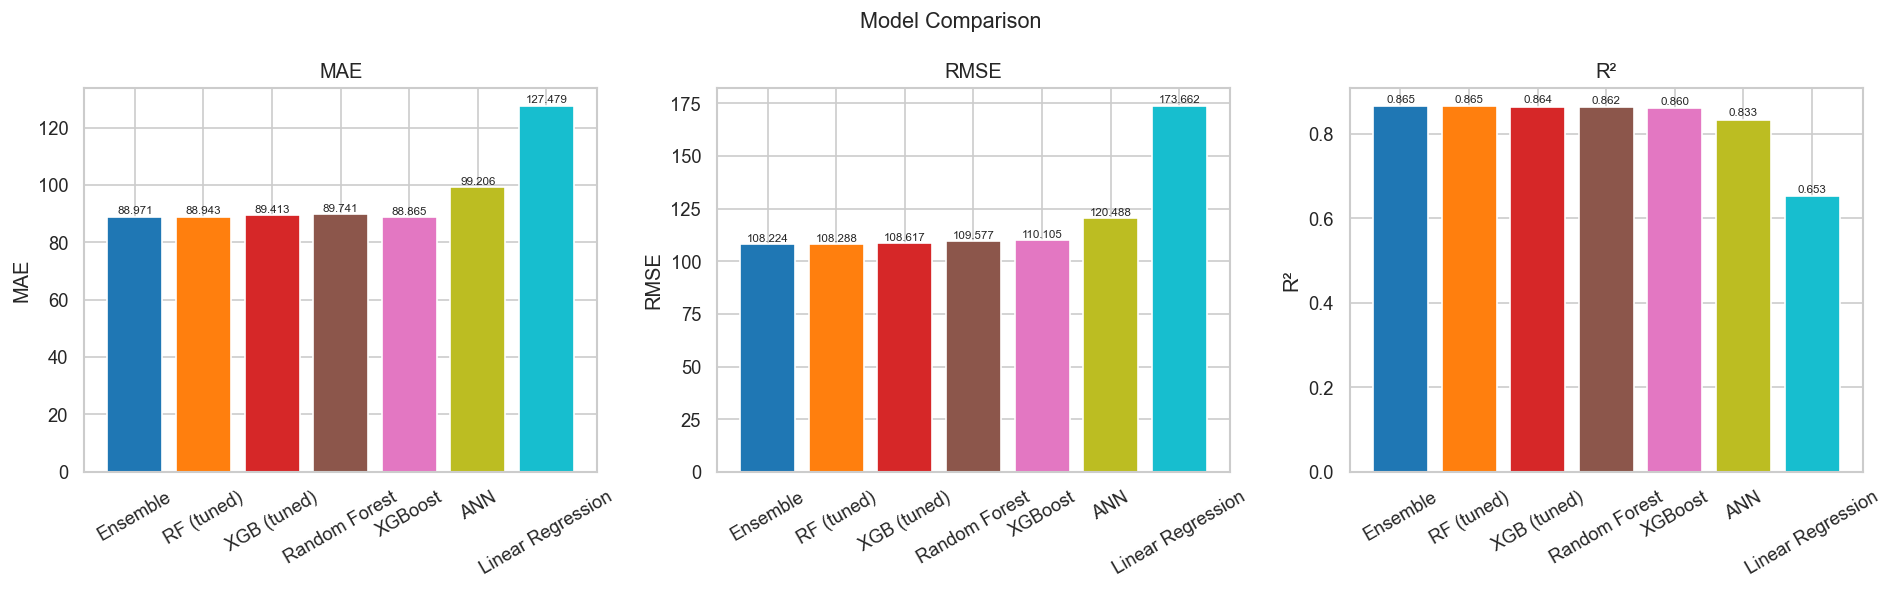

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(comp)))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    bars = ax.bar(comp['Model'], comp[metric], color=colors)
    ax.set_title(metric); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, comp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, f'{val:.3f}', ha='center', fontsize=7)
plt.suptitle('Model Comparison', fontsize=13)
plt.tight_layout(); plt.show()

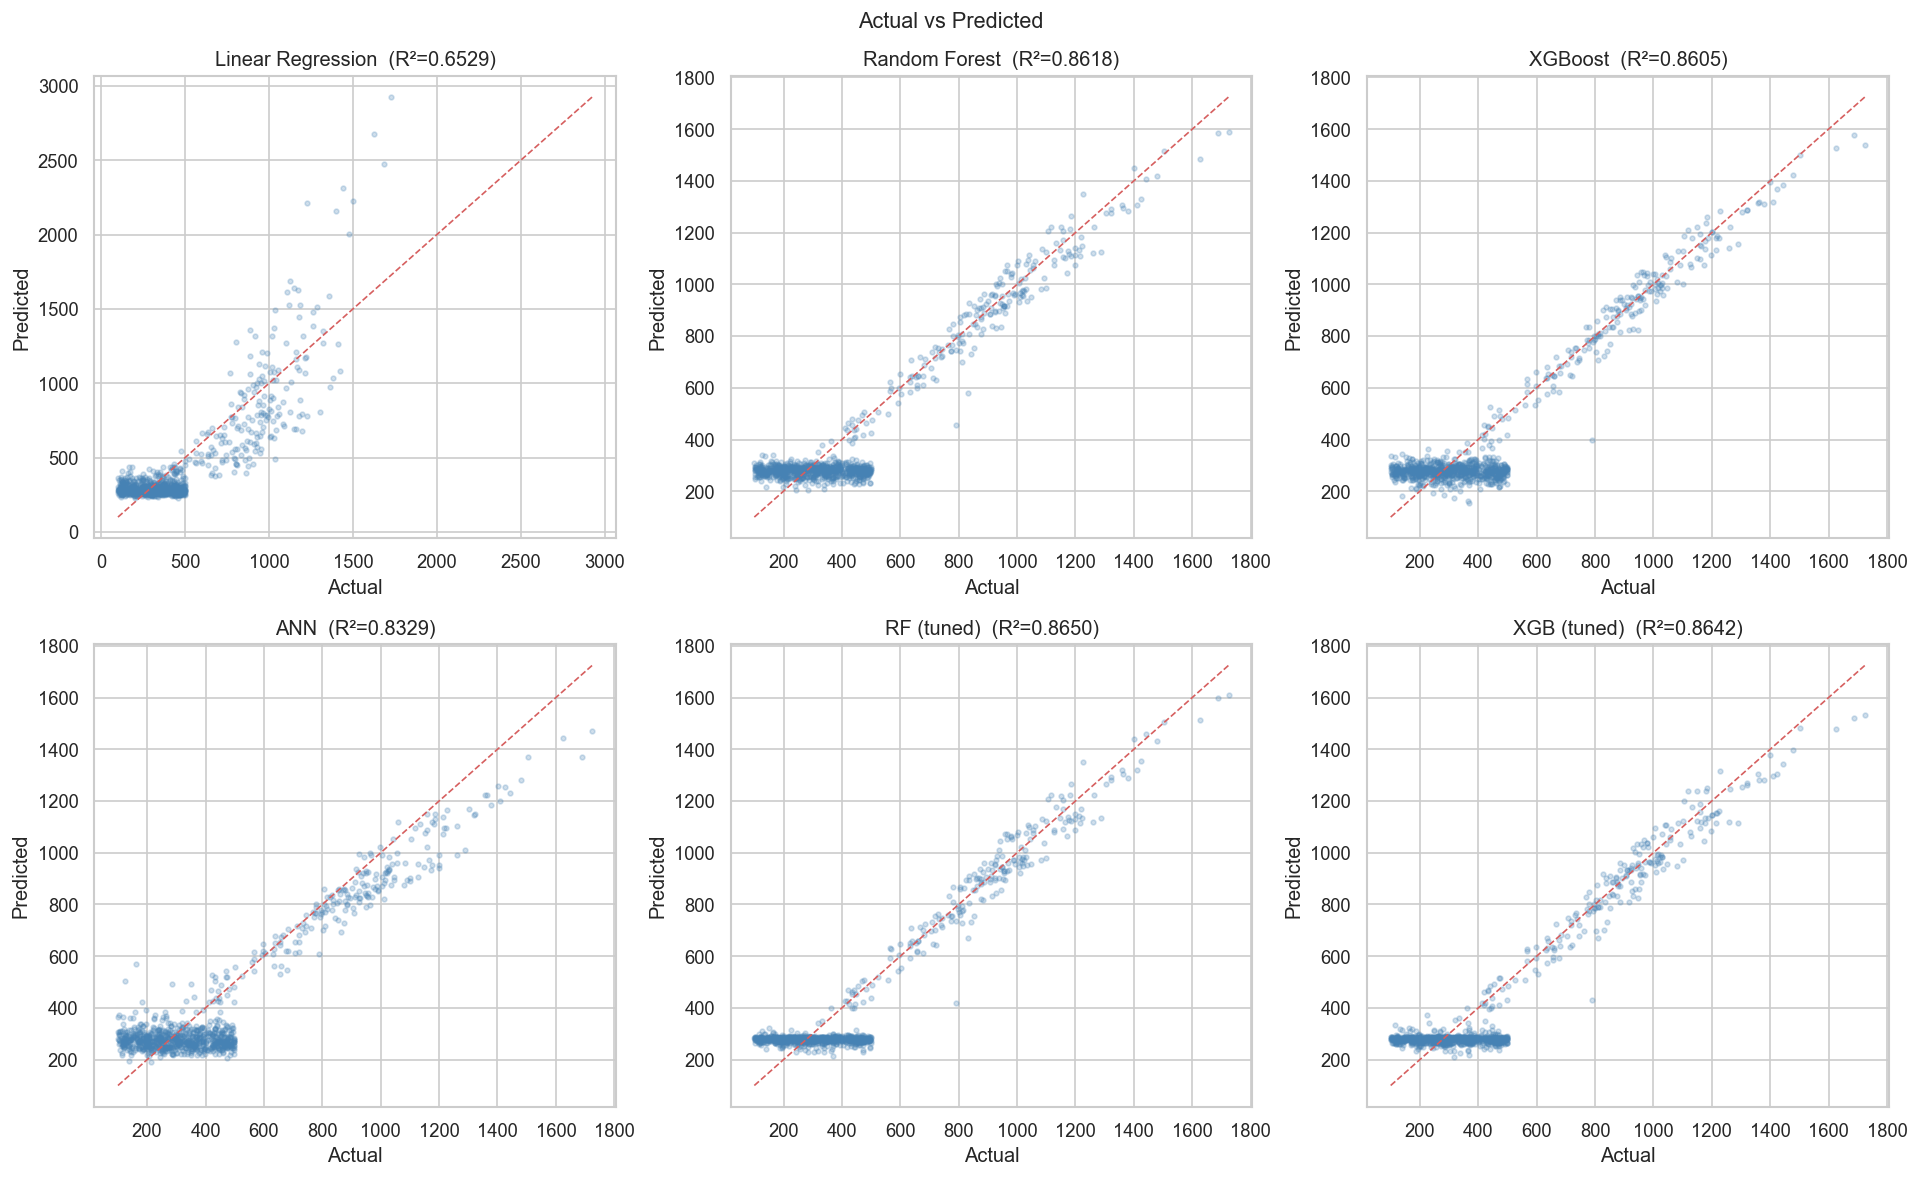

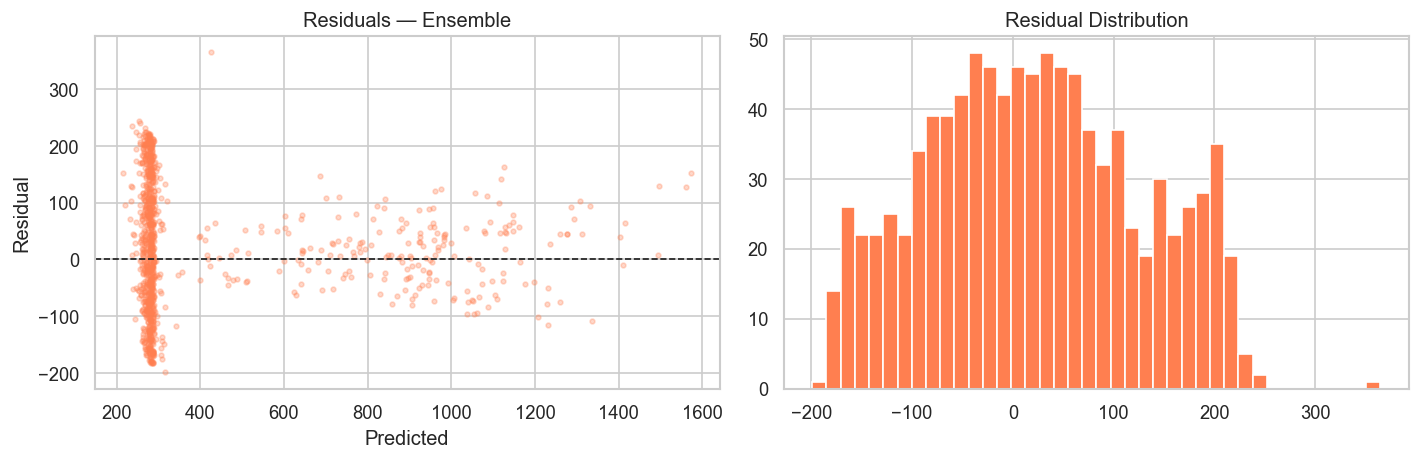

In [37]:
# Actual vs Predicted plots for all models
all_preds = {
    'Linear Regression': pred_lr, 'Random Forest': pred_rf,
    'XGBoost': pred_xgb, 'ANN': pred_ann,
    'RF (tuned)': pred_rf_tuned, 'XGB (tuned)': pred_xgb_tuned
}
n = len(all_preds); nc = 3; nr = (n + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(16, 5 * nr))
axes = axes.flatten()
for ax, (name, pred) in zip(axes, all_preds.items()):
    ax.scatter(y_test_raw, pred, alpha=0.25, s=8, color='steelblue')
    lims = [min(y_test_raw.min(), pred.min()), max(y_test_raw.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(f'{name}  (R²={results[name]["R2"]:.4f})')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
for ax in axes[n:]: ax.set_visible(False)
plt.suptitle('Actual vs Predicted', fontsize=13)
plt.tight_layout(); plt.show()

# Residual analysis — best model
bp_map = {**all_preds, 'Ensemble': pred_ens}
bp = bp_map.get(best_model_name, pred_rf_tuned)
residuals = y_test_raw.values - bp
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(bp, residuals, alpha=0.3, s=8, color='coral')
axes[0].axhline(0, color='k', lw=1, ls='--')
axes[0].set_title(f'Residuals — {best_model_name}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Residual Distribution')
plt.tight_layout(); plt.show()

In [38]:
# Per-source performance breakdown
print('=== R² by dataset source ===')
rows = []
for name, pred in {**all_preds,'Ensemble':pred_ens}.items():
    for sv, label in [(0,'DS1 Gym'),(1,'DS2 Fitness')]:
        m = (src_test == sv)
        if m.sum() > 5:
            rows.append({'Model':name,'Source':label,
                'R²': round(r2_score(y_test_raw[m], pred[m.values]), 4),
                'MAE': round(mean_absolute_error(y_test_raw[m], pred[m.values]), 1),
                'N':   int(m.sum())})
src_df = pd.DataFrame(rows)
display(src_df.pivot_table(index='Model', columns='Source',
                           values=['R²','MAE'], aggfunc='first').round(4))

=== R² by dataset source ===


MAE                  R²            
Source            DS1 Gym DS2 Fitness DS1 Gym DS2 Fitness
Model                                                    
ANN                  81.7       104.1  0.8403     -0.1818
Ensemble             48.5       100.2  0.9440     -0.0625
Linear Regression   218.0       102.4 -0.2129     -0.1357
RF (tuned)           47.8       100.3  0.9457     -0.0665
Random Forest        50.3       100.7  0.9411     -0.0871
XGB (tuned)          50.8       100.1  0.9379     -0.0617
XGBoost              41.8       101.9  0.9525     -0.1155

## Save Model & Pipeline Artifacts

In [39]:
import shutil
# FIX: clean out/ before saving so stale artifacts from previous runs
# (e.g. imputer_models.pkl from an older pipeline version) do not mislead.
if os.path.exists('out'):
    shutil.rmtree('out')
os.makedirs('out', exist_ok=True)

try:    _rf_s  = rf_tuned
except: _rf_s  = rf
try:    _xgb_s = xgb_tuned
except: _xgb_s = xgb

_objs = {
    'Linear Regression': lr, 'Random Forest': rf, 'XGBoost': xgb,
    'RF (tuned)': _rf_s, 'XGB (tuned)': _xgb_s,
}

if best_model_name == 'ANN':
    ann.save('out/best_model_ann.keras')
    print('Saved: best_model_ann.keras')
elif best_model_name == 'Ensemble':
    joblib.dump(_rf_s,  'out/ensemble_rf.pkl')
    joblib.dump(_xgb_s, 'out/ensemble_xgb.pkl')
    ann.save('out/ensemble_ann.keras')
    print('Saved ensemble components.')
elif best_model_name in _objs:
    joblib.dump(_objs[best_model_name], 'out/best_model.pkl')
    print(f'Saved: best_model.pkl ({best_model_name})')

joblib.dump(scaler,            'out/scaler.pkl')
joblib.dump(selected_features, 'out/feature_list.pkl')
joblib.dump(impute_values,     'out/impute_values.pkl')
fs_scores.round(4).to_csv('out/feature_selection_scores.csv')

_wt = [c.replace('wt_', '') for c in selected_features if c.startswith('wt_')]
enc = {
    'weather_map'      : {'Sunny': 2, 'Cloudy': 1, 'Rainy': 0},
    'gender_map'       : {'Male': 1, 'Female': 0},
    'workout_types'    : _wt,
    'feature_list'     : selected_features,
    'best_model'       : best_model_name,
    'calorie_bins'     : CALORIE_BINS,
    'calorie_labels'   : CALORIE_LABELS,
    'target_transform' : 'log1p',
    'ensemble_weights' : {'rf': float(w_rf), 'xgb': float(w_xgb), 'ann': float(w_ann)},
}
with open('out/encoding_maps.json', 'w') as f:
    _json.dump(enc, f, indent=2)

print('\nAll artifacts (clean run):')
for fn in sorted(os.listdir('out')): print(f'  {fn}')

Saved ensemble components.

All artifacts (clean run):
  encoding_maps.json
  ensemble_ann.keras
  ensemble_rf.pkl
  ensemble_xgb.pkl
  feature_list.pkl
  feature_selection_scores.csv
  impute_values.pkl
  scaler.pkl


# Sanity Check, Load & Predict

In [40]:
_sc   = joblib.load('out/scaler.pkl')
_feats= joblib.load('out/feature_list.pkl')
with open('out/encoding_maps.json') as f: _enc = _json.load(f)
_ew = _enc['ensemble_weights']

_raw = X_test.iloc[:10][_feats]
_sc2 = _sc.transform(_raw)

if best_model_name == 'ANN':
    from tensorflow.keras.models import load_model as _lm
    plog = _lm('out/best_model_ann.keras').predict(_sc2).flatten()
elif best_model_name == 'Ensemble':
    from tensorflow.keras.models import load_model as _lm
    _r=joblib.load('out/ensemble_rf.pkl'); _x=joblib.load('out/ensemble_xgb.pkl')
    _a=_lm('out/ensemble_ann.keras')
    plog = _ew['rf']*_r.predict(_raw) + _ew['xgb']*_x.predict(_raw) + _ew['ann']*_a.predict(_sc2).flatten()
else:
    _m = joblib.load('out/best_model.pkl')
    plog = _m.predict(_sc2) if best_model_name=='Linear Regression' else _m.predict(_raw)

pcal = np.expm1(np.clip(plog, 0, None))
acts = y_test_raw.values[:10]

print(f'Sanity check — {best_model_name}:')
print(f'{"#":<4} {"Actual":>8} {"Predicted":>10} {"Error":>7} {"OK":>4} {"Zone":>10}')
print('-'*50)
for i,(a,p) in enumerate(zip(acts,pcal)):
    zone = CALORIE_LABELS[min(np.searchsorted(CALORIE_BINS[1:],a), len(CALORIE_LABELS)-1)]
    err=abs(a-p)
    print(f'{i+1:<4} {a:>8.0f} {p:>10.0f} {err:>7.0f} {"✓" if err<=100 else "✗":>4} {zone:>10}')
print(f'\nAcc±100: {(np.abs(acts-pcal)<=100).mean()*100:.1f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Sanity check — Ensemble:
#      Actual  Predicted   Error   OK       Zone
--------------------------------------------------
1         261        282      21    ✓        Low
2         128        280     153    ✗        Low
3         194        266      72    ✓        Low
4         203        288      85    ✓        Low
5         442        273     168    ✗     Medium
6         181        287     107    ✗        Low
7         268        263       4    ✓        Low
8         169        287     119    ✗        Low
9         262        275      13    ✓        Low
10        477        285     192    ✗     Medium

Acc±100: 50.0%


## Web App Inference Reference
Documents what the application must supply at prediction time.

In [41]:
# Web App Inference Reference
SOURCE_MAP = {
    'Age':'profile', 'Gender':'profile', 'Weight (kg)':'profile',
    'BMI':'profile (auto)', 'Resting_BPM':'profile',
    'Fat_Percentage':'profile', 'Experience_Level':'profile',
    'Workout_Frequency (days/week)':'profile',
    'Session_Duration (hours)':'daily session',
    'Avg_BPM':'daily session', 'Exercise_Intensity':'daily session',
    'Water_Intake (liters)':'daily session',
    'Weather_Conditions':'OpenWeather API',
}
DERIVED = {'HR_Duration','Intensity_Duration','Weight_Duration','BMI_Duration',
           'HR_Reserve','Max_BPM_calc','HR_Intensity_Ratio'}
WT_COLS = {c for c in selected_features if c.startswith('wt_')}

print('Model input features at inference time:')
print(f'{"Feature":<38} {"Source"}')
print('-'*60)
for i, f in enumerate(selected_features, 1):
    if f in SOURCE_MAP:  src = SOURCE_MAP[f]
    elif f in DERIVED:   src = 'computed from above'
    elif f in WT_COLS:   src = 'daily session (one-hot)'
    else:                src = '?'
    print(f'{i:2d}. {f:<36} {src}')

print(f'\nTotal features: {len(selected_features)}')
print('\nNote: source is NOT a model feature.')
print('Sample weights handle DS1/DS2 imbalance during training.')
print('\nCalorie goal formula (app logic, NOT model):')
print('  daily_target = (current_weight - dream_weight) * 7700 / days_to_goal')

Model input features at inference time:
Feature                                Source
------------------------------------------------------------
 1. Session_Duration (hours)             daily session
 2. HR_Duration                          computed from above
 3. BMI_Duration                         computed from above
 4. Experience_Level                     profile
 5. Weight (kg)                          profile
 6. HR_Intensity_Ratio                   computed from above
 7. Weight_Duration                      computed from above
 8. BMI                                  profile (auto)
 9. Intensity_Duration                   computed from above
10. Avg_BPM                              daily session

Total features: 10

Note: source is NOT a model feature.
Sample weights handle DS1/DS2 imbalance during training.

Calorie goal formula (app logic, NOT model):
  daily_target = (current_weight - dream_weight) * 7700 / days_to_goal
